### SWIGGY SALES ANALYSIS

#### IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


#### IMPORT DATA

In [2]:
date= pd.read_csv("E:/Data Analyst Projects/Swiggy Analysis/Data/dim_date.csv")

In [3]:
dish = pd .read_csv("E:/Data Analyst Projects/Swiggy Analysis/Data/dim_dish.csv")


In [32]:
dish.head(10)

,dish_id,category,dish_name
0,1,Snack,Butter Murukku200gm
1,2,Recommended,Badam Milk
2,3,Recommended,Chow Chow Bath
3,4,Recommended,Kesari Bath
4,5,Recommended,Mix Raitha
5,6,Recommended,Srinidhi Sagar Special
6,7,Recommended,Garlic Naan
7,8,Recommended,Pista
8,9,North Indian Gravy,Panneer Butter Masala
9,10,North Indian Gravy,Dal Tadka


In [4]:
location = pd.read_csv("E:/Data Analyst Projects/Swiggy Analysis/Data/dim_location.csv")

In [5]:
restaurant = pd.read_csv("E:/Data Analyst Projects/Swiggy Analysis/Data/dim_restaurant.csv")

In [6]:
orders = pd.read_csv("E:/Data Analyst Projects/Swiggy Analysis/Data/fact_orders.csv")

#### DATATYPES

In [14]:
date.dtypes

date_id                int64
order_date    datetime64[ns]
dtype: object

In [13]:
date['order_date']=pd.to_datetime(date['order_date'])

C:\Users\admin\AppData\Local\Temp\ipykernel_14928\4105683097.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date['order_date']=pd.to_datetime(date['order_date'])


In [ ]:
dish.dtypes

In [ ]:
location.dtypes

In [48]:
location.head(10)

,location_id,state,city,location
0,1,Karnataka,Bengaluru,Rajarajeshwari Nagar
1,2,Karnataka,Bengaluru,Kengeri
2,3,Karnataka,Bengaluru,Kanmanike Village
3,4,Karnataka,Bengaluru,Bidadi
4,5,Karnataka,Bengaluru,Kengeri Satellite Town
5,6,Karnataka,Bengaluru,Kanakapura Road
6,7,Karnataka,Bengaluru,Jawaharlal Nehru Road
7,8,Karnataka,Bengaluru,KENGERI UPANAGAR
8,9,Karnataka,Bengaluru,Rr Nagar
9,10,Karnataka,Bengaluru,Gopalan Arcade Mall


In [ ]:
restaurant.dtypes

In [ ]:
orders.dtypes

### KPI'S

#### TOTAL SALES 

In [ ]:
total_sales= orders['price'].sum()
print("Total Sales:",round(total_sales,2))

#### AVERAGE RATING

In [ ]:
avg_ratings= orders["rating"].mean()
print("Avg Ratings:",round(avg_ratings,1))

#### AVERAGE ORDER VALUE 

In [ ]:
avg_order_value = orders['price'].mean()
print('Avg Order Value:', round(avg_order_value,2))


#### RATINGS COUNT

In [ ]:
ratings_count = orders['rating_count'].sum()
print("Rating Count:",round(ratings_count,2))

#### TOTAL ORDERS

In [ ]:
total_orders= orders['order_id'].count()
print("Total Orders:",total_orders)

### CHARTS DESIGN

#### MONTHLY SALES TREND

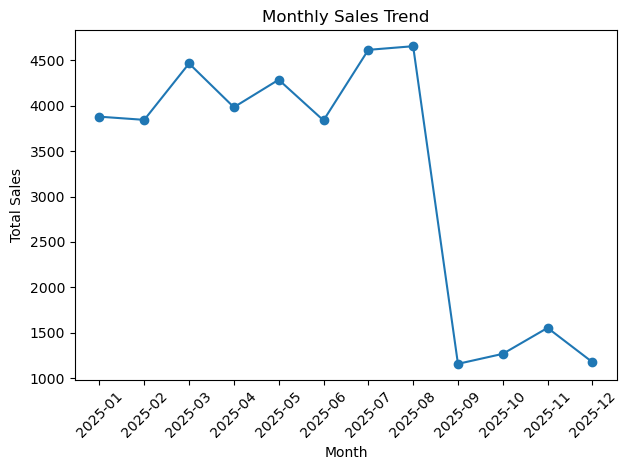

In [16]:
date['YearMonth']= date['order_date'].dt.to_period('M').astype(str)
date['revenue']=orders['price']
monthly_revenue = date.groupby('YearMonth')['revenue'].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue['YearMonth'],monthly_revenue['revenue'],marker='o')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.tight_layout()
plt.show()

#### DAILY SALES TREND

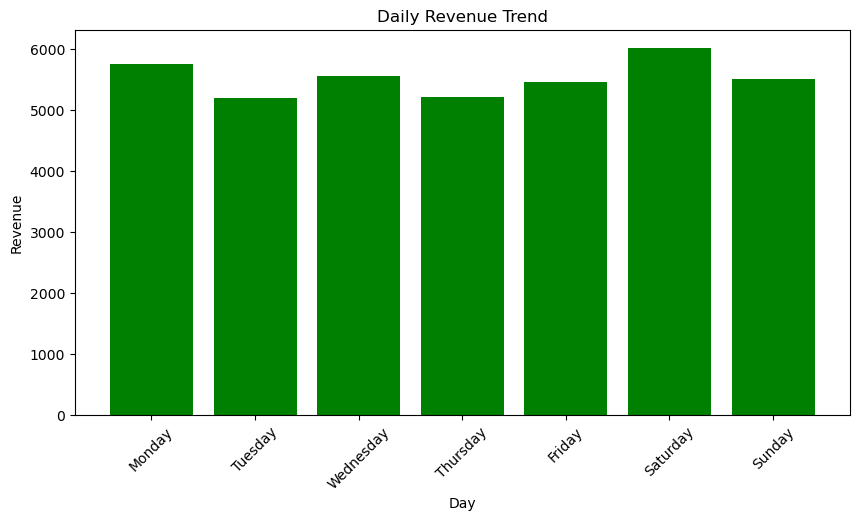

In [30]:
date['dayname']=pd.to_datetime(date['order_date']).dt.day_name()
date['revenue']=orders['price']
daily_revenue=(
    date.groupby('dayname')['revenue'].sum().reindex(["Monday",'Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
)

plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index,daily_revenue.values,color='green')
plt.title('Daily Revenue Trend')
plt.xlabel('Day')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()


#### TOTAL SALES BY FOOD TYPE 

In [40]:
non_veg_keywords = ['chicken','egg','fish','mutton','prawn','biryani','kabab','kebab','non-veg','non veg']
dish['food category']=np.where(dish['dish_name'].str.lower().str.contains("|".join(non_veg_keywords),na=False),
                               'Non-Veg',
                               'Veg')



In [43]:
dish['revenue']=orders['price']
food_revenue =(dish.groupby('food category')['revenue'].sum().reset_index())

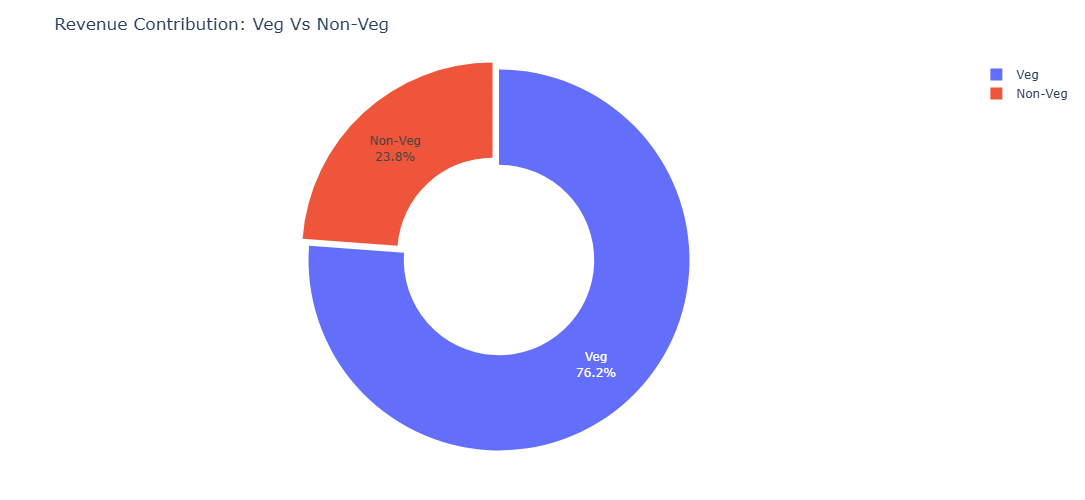

In [47]:
fig=px.pie(
    food_revenue,
    values='revenue',
    names='food category',
    hole=0.5,
    title = "Revenue Contribution: Veg Vs Non-Veg",
    )

fig.update_traces(
    textinfo='percent+label',
    pull=[0.05,0]
)
fig.update_layout(
    height=500,
    margin=dict(t=60,b=40,l=40,r=40)
) 
fig.show()


#### TOTAL SALES BY STATE

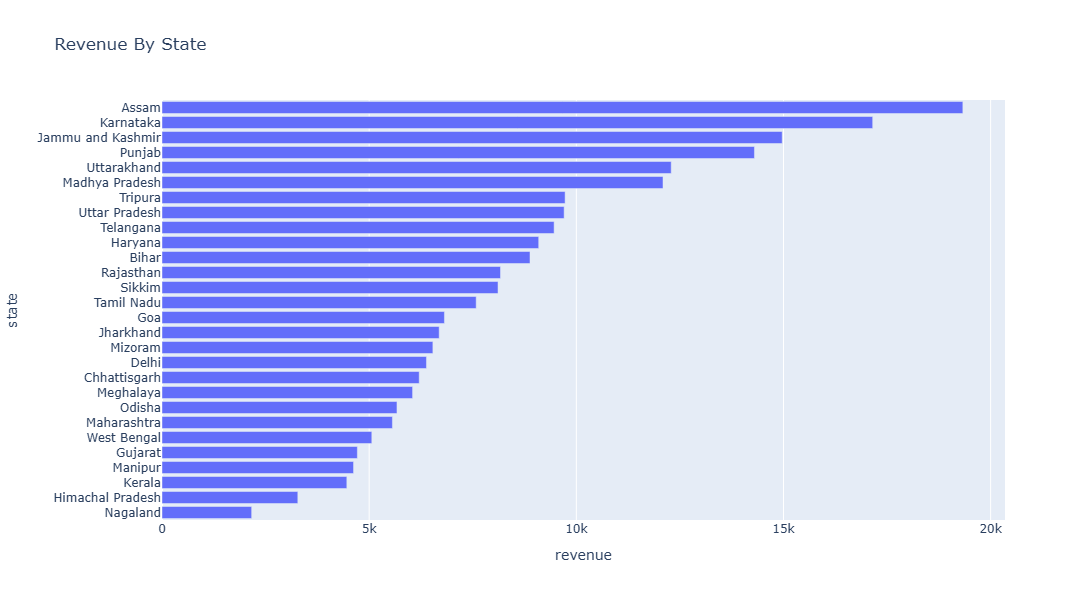

In [54]:
location['revenue']=orders['price']
fig=px.bar(
    location.groupby('state',as_index=False)['revenue'].sum()
    .sort_values('revenue',ascending=False),
x='revenue',
y='state',
orientation='h',
title='Revenue By State'
)
fig.update_layout(height=600,yaxis=dict(autorange='reversed'))
fig.show()


#### QUARTERLY PERFORMANCE SUMMARY

date['revenue']=orders['price']
date['rating']=orders['rating']
date['order_id']=orders['order_id']
date['order_date']=pd.to_datetime(date['order_date'])
date['quarter']=date['order_date'].dt.to_period('Q').astype(str)
quarterly_summary=(
    date.groupby('quarter',as_index=False)
    .agg(
    Total_Sales=('revenue','sum'),
    Avg_Rating= ('rating','mean'),
    Total_Orders=('order_id','count')
    ).sort_values('quarter'))


quarterly_summary
                 

    


#### TOP 5 CITIES BY STATES


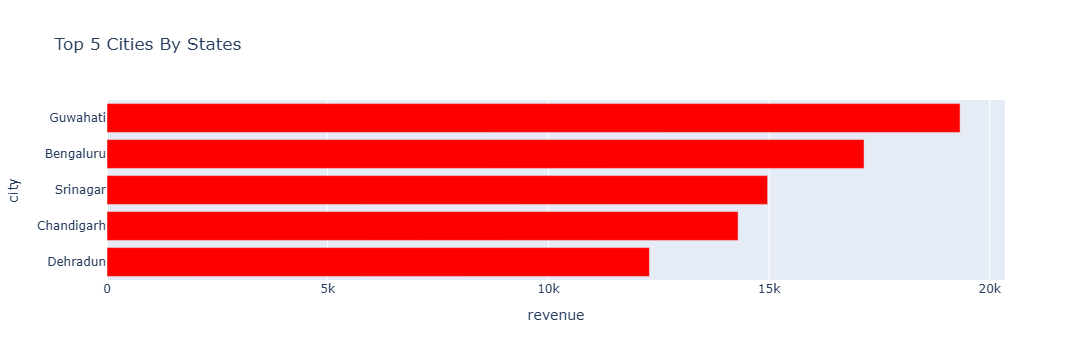

In [70]:
location['revenue']=orders['price']
top_5_cities=(
    location.groupby('city')['revenue'].sum()
    .nlargest(5).sort_values().reset_index()
)

fig=px.bar(
    top_5_cities,
    x='revenue',
    y='city',
    orientation='h',
    title='Top 5 Cities By States',
    color_discrete_sequence=['red']
)
fig.show()

